# **Hybrid Deep Learining Model - SOM + ANN**

**Importing Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Importing dataset**

In [2]:
dataset=pd.read_csv('Credit_Card_Applications.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

**Featuer Scaling**

In [3]:

from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler(feature_range=(0,1))
X=sc.fit_transform(X)

In [4]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=9b3ace92d42a18d6c51f76696a8f666ce0a6b0cc0ade6850584b84bbb9bc8f4d
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


**Training the SOM**

In [5]:
from minisom import MiniSom
som=MiniSom(x=10,y=10,input_len=15,sigma=1.0,learning_rate=0.5)
som.random_weights_init(X)
som.train_random(data=X,num_iteration=100)

**Visualizing the Result**

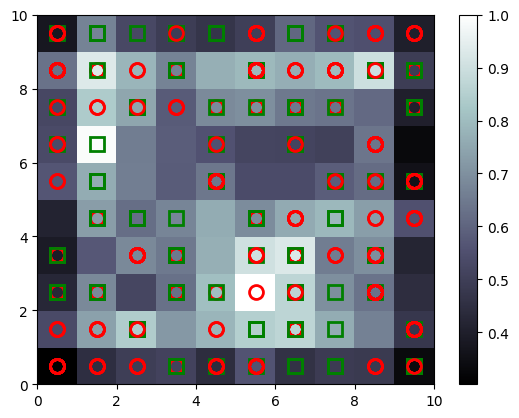

In [6]:
from pylab import bone,pcolor,colorbar,plot,show
bone()
pcolor(som.distance_map().T)
colorbar()
markers=['o','s']
colors=['r','g']
for i,x in enumerate(X):
  w=som.winner(x)
  plot(w[0]+0.5,w[1]+0.5,markers[y[i]],markeredgecolor=colors[y[i]],markerfacecolor='None',markersize=10,markeredgewidth=2)
show()

**Finding the Fraudes**

In [7]:
mapping = som.win_map(X)
frauds = np.concatenate((mapping[(6,3)], mapping[(7,9)]), axis = 0)
frauds = sc.inverse_transform(frauds)

In [8]:
from IPython.display import display


fraud_df = pd.DataFrame(frauds, columns=dataset.drop('Class', axis=1).columns)
display(fraud_df)

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,15731586.0,0.0,29.50,2.000,1.0,10.0,8.0,2.000,0.0,0.0,0.0,0.0,2.0,256.0,18.0
1,15575605.0,0.0,24.75,13.665,2.0,11.0,8.0,1.500,0.0,0.0,0.0,0.0,2.0,280.0,2.0
2,15644453.0,0.0,18.17,10.000,1.0,11.0,8.0,0.165,0.0,0.0,0.0,0.0,2.0,340.0,1.0
3,15699238.0,0.0,22.50,8.460,1.0,14.0,4.0,2.460,0.0,0.0,0.0,0.0,2.0,164.0,1.0
4,15577771.0,0.0,29.50,1.085,1.0,14.0,4.0,1.000,0.0,0.0,0.0,0.0,2.0,280.0,14.0
5,15599272.0,0.0,33.67,0.375,2.0,13.0,4.0,0.375,0.0,0.0,0.0,0.0,2.0,300.0,45.0
6,15638610.0,0.0,55.75,7.080,2.0,4.0,8.0,6.750,1.0,1.0,3.0,1.0,2.0,100.0,51.0
7,15789611.0,0.0,47.75,8.000,2.0,8.0,4.0,7.875,1.0,1.0,6.0,1.0,2.0,0.0,1261.0
8,15668679.0,0.0,47.42,3.000,2.0,14.0,4.0,13.875,1.0,1.0,2.0,1.0,2.0,519.0,1705.0
9,15738487.0,0.0,20.75,10.250,2.0,11.0,4.0,0.710,1.0,1.0,2.0,1.0,2.0,49.0,1.0


# Unsupervised to supervised

**Creating the matrix of features**

In [9]:
customers=dataset.iloc[:,1:].values

**creating the dependent variable**

In [10]:
is_fraud=np.zeros(len(dataset))
for i in range(len(dataset)):
  if dataset.iloc[i,0] in frauds:
    is_fraud[i]=1
  else:
    is_fraud[i]=0

# ANN part

In [11]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
customers=sc.fit_transform(customers)

In [12]:
from keras.models import Sequential
from keras.layers import Dense

In [13]:
classifier=Sequential()
classifier.add(Dense(units=2,kernel_initializer='uniform',activation='relu',input_dim=15))
classifier.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
classifier.fit(customers,is_fraud,batch_size=1,epochs=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
690/690 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9623 - loss: 0.4543
Epoch 2/2
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9623 - loss: 0.1696


In [14]:
y_pred=classifier.predict(customers)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [15]:
y_pred=np.concatenate((dataset.iloc[:,0:1].values,y_pred),axis=1)

In [22]:
sorted_preds = y_pred[y_pred[:, 1].argsort()]
